<a href="https://colab.research.google.com/github/lalitha-sahitya/Handwritten-digit-recognition/blob/main/digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os

In [24]:
!pip install opendatasets

In [25]:
import opendatasets as od

In [26]:
od.download('https://www.kaggle.com/competitions/digit-recognizer')

Skipping, found downloaded files in "./digit-recognizer" (use force=True to force download)


In [27]:
os.listdir('digit-recognizer')

['test.csv', 'sample_submission.csv', 'train.csv']

In [50]:
import pandas as pd
import numpy as np

In [51]:
data=pd.read_csv('/content/digit-recognizer/train.csv')

In [52]:
test_data=pd.read_csv('/content/digit-recognizer/test.csv')

In [53]:
data.shape

(42000, 785)

In [54]:
data_arr=[]
for i in range(data.shape[0]):
  data_arr.append(np.array(data.iloc[i,1:]).reshape(28,28))

In [55]:
import matplotlib.pyplot as plt

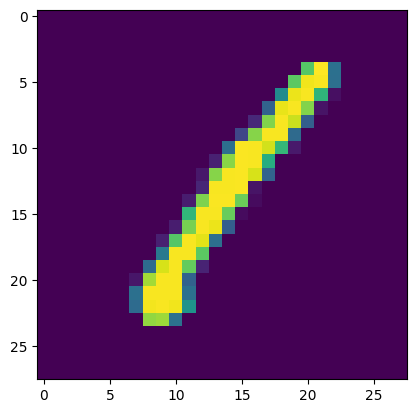

In [56]:
plt.imshow(data_arr[0])

In [57]:
data.iloc[0][0]

<ipython-input-57-a5649ad43205>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.iloc[0][0]


1

In [58]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
data.iloc[0][1]

<ipython-input-59-af1b558ac0a9>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.iloc[0][1]


0

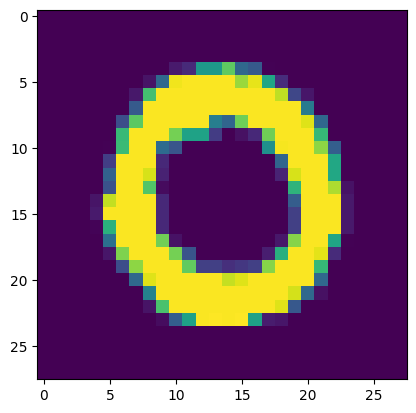

In [60]:
plt.imshow(data_arr[1])

In [61]:
test_arr=[]
for i in range(test_data.shape[0]):
  test_arr.append(np.array(test_data.iloc[i,:]).reshape(28,28))

In [63]:
test_arr=np.array(test_arr)

In [64]:
test_arr.shape

(28000, 28, 28)

In [65]:
data_arr=np.array(data_arr)

In [66]:
data_arr.shape

(42000, 28, 28)

In [67]:
data_arr=data_arr/255
test_arr=test_arr/255

In [68]:
data_arr=data_arr.reshape(len(data_arr),28*28)
test_arr=test_arr.reshape(len(test_arr),28*28)

In [69]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [70]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dropout(0.2),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [72]:
history=model.fit(data_arr,data.iloc[:,0],epochs=10,validation_split=0.1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8299 - loss: 0.5819 - val_accuracy: 0.9452 - val_loss: 0.1872
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9457 - loss: 0.1836 - val_accuracy: 0.9602 - val_loss: 0.1270
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9619 - loss: 0.1246 - val_accuracy: 0.9667 - val_loss: 0.1111
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9678 - loss: 0.1054 - val_accuracy: 0.9686 - val_loss: 0.0984
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9751 - loss: 0.0827 - val_accuracy: 0.9721 - val_loss: 0.0961
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9779 - loss: 0.0745 - val_accuracy: 0.9729 - val_loss: 0.0889
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9808 - loss: 0.0616 - val_accuracy: 0.9760 - val_loss: 0.0841
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9837 - loss: 0.0520 -

In [73]:
preds=model.predict(test_arr)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [75]:
preds=np.argmax(preds,axis=1)

In [76]:
preds

array([2, 0, 9, ..., 3, 9, 2])

In [85]:
sub=pd.read_csv('/content/digit-recognizer/sample_submission.csv')

In [86]:
sub.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [87]:
sub['Label']=preds

In [88]:
sub

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [89]:
sub.to_csv('sub.csv',index=False)